In [9]:


import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [10]:

train_path = "/kaggle/input/datasets/vrajesh0sharma7/30-musical-instruments/dataset/train"
valid_path = "/kaggle/input/datasets/vrajesh0sharma7/30-musical-instruments/dataset/valid"
test_path  = "/kaggle/input/datasets/vrajesh0sharma7/30-musical-instruments/dataset/test"

In [11]:
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [12]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4793 images belonging to 30 classes.
Found 150 images belonging to 30 classes.
Found 150 images belonging to 30 classes.


In [13]:
model = tf.keras.models.Sequential()

# Block 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

# Block 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

# Block 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

# Block 4 
model.add(tf.keras.layers.Conv2D(256, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(2,2))

# Flatten
model.add(tf.keras.layers.Flatten())

# Dense
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))

model.add(tf.keras.layers.Dense(train_data.num_classes, activation='softmax'))

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [17]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 285ms/step - accuracy: 0.2461 - loss: 2.7719 - val_accuracy: 0.1667 - val_loss: 3.8021 - learning_rate: 5.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 296ms/step - accuracy: 0.2958 - loss: 2.6046 - val_accuracy: 0.4067 - val_loss: 2.0294 - learning_rate: 5.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.3465 - loss: 2.3656 - val_accuracy: 0.5933 - val_loss: 1.6092 - learning_rate: 5.0000e-04
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.3856 - loss: 2.2493 - val_accuracy: 0.5933 - val_loss: 1.4110 - learning_rate: 5.0000e-04
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 27s 181ms/step - accuracy: 0.4146 - loss: 2.1204 - val_accuracy: 0.5600 - val_loss: 1.4961 - learning_rate: 5.0000e-04
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 188ms/step - accuracy: 0.4298 - loss: 2.0352 - val_accuracy: 0.6400 - val_loss: 1.5721 - learning_rate: 5.0000e-04
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 24

In [18]:
val_loss, val_acc = model.evaluate(valid_data)
print("Validation Accuracy:", val_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8023 - loss: 0.7041
Validation Accuracy: 0.800000011920929


In [19]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.7729 - loss: 0.7567
Test Accuracy: 0.7599999904632568


In [20]:
from sklearn.metrics import classification_report

test_data.reset()

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step
              precision    recall  f1-score   support

  Didgeridoo       0.00      0.00      0.00         5
  Tambourine       0.00      0.00      0.00         5
   Xylophone       0.00      0.00      0.00         5
    acordian       0.17      0.20      0.18         5
     alphorn       0.00      0.00      0.00         5
    bagpipes       0.00      0.00      0.00         5
       banjo       0.00      0.00      0.00         5
  bongo drum       0.00      0.00      0.00         5
      casaba       0.17      0.20      0.18         5
   castanets       0.00      0.00      0.00         5
    clarinet       0.00      0.00      0.00         5
  clavichord       0.10      0.20      0.13         5
  concertina       0.00      0.00      0.00         5
       drums       0.00      0.00      0.00         5
    dulcimer       0.00      0.00      0.00         5
       flute       0.00      0.00      0.00         5
       guiro       0.00      0.00      0.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


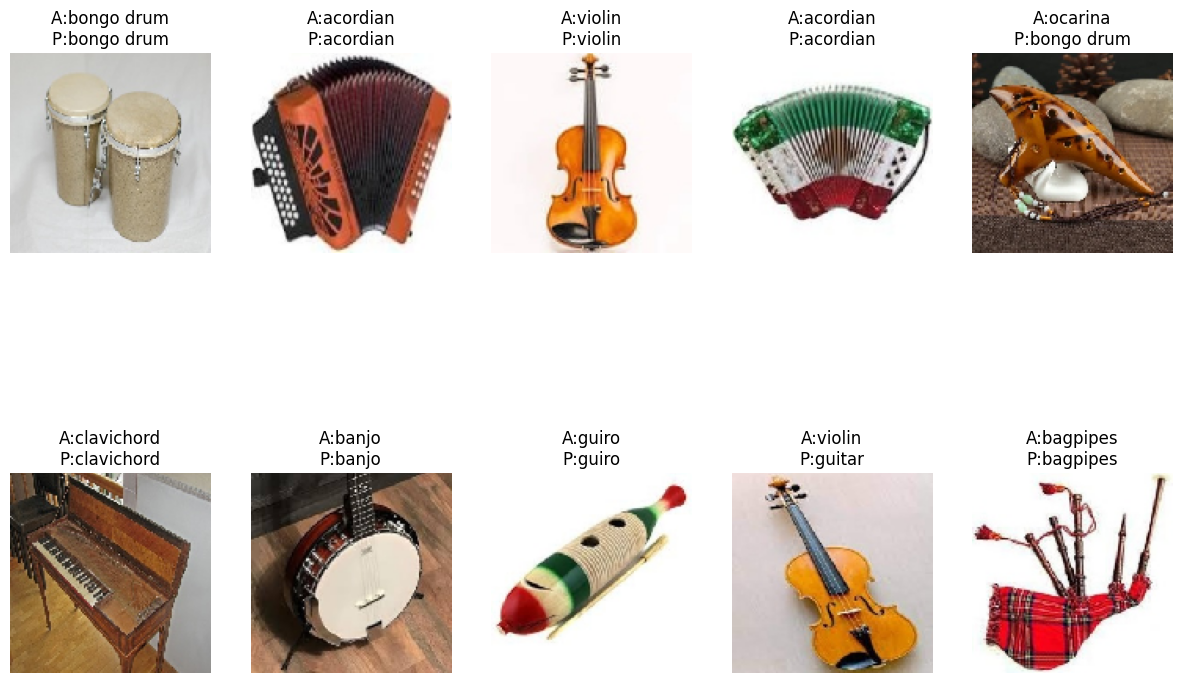

In [23]:
import random
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

image_paths = []
labels = []

for class_name in os.listdir(test_path):
    folder = os.path.join(test_path, class_name)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(class_name)

random_indices = random.sample(range(len(image_paths)), 10)

plt.figure(figsize=(15,10))

for i, idx in enumerate(random_indices):
    img_path = image_paths[idx]
    actual = labels[idx]
    
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    pred = model.predict(img_array)
    pred_class = class_labels[np.argmax(pred)]
    
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"A:{actual}\nP:{pred_class}")
    plt.axis("off")

plt.show()

In [24]:
print("Predictions with Confidence:\n")

for i, idx in enumerate(random_indices):
    img_path = image_paths[idx]
    actual = labels[idx]
    
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    pred = model.predict(img_array)
    
    pred_idx = np.argmax(pred)
    pred_class = class_labels[pred_idx]
    confidence = pred[0][pred_idx]
    
    print(f"Image {i+1}")
    print(f"Actual: {actual}")
    print(f"Predicted: {pred_class}")
    print(f"Confidence: {confidence:.4f}")
    print("-"*30)

Predictions with Confidence:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Image 1
Actual: bongo drum
Predicted: bongo drum
Confidence: 0.9999
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Image 2
Actual: acordian
Predicted: acordian
Confidence: 0.9880
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Image 3
Actual: violin
Predicted: violin
Confidence: 0.9995
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Image 4
Actual: acordian
Predicted: acordian
Confidence: 0.9964
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Image 5
Actual: ocarina
Predicted: bongo drum
Confidence: 0.1931
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Image 6
Actual: clavichord
Predicted: clavichord
Confidence: 0.9661
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Image 7
Actual: banjo
Predicted: banjo
Confidence: 0.3029
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Im

In [25]:
model.save("/kaggle/working/cnn_model.h5")